<a href="https://colab.research.google.com/github/Neha609/Machine-Learning-Projects/blob/gh-pages/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [32]:
# ==========================================
# 1. DATASET CREATION & PREPROCESSING
# ==========================================
np.random.seed(42)
n_records = 300

In [33]:
# Generating realistic financial predictors
credit_score = np.random.randint(400, 850, n_records)
debt_to_income = np.random.uniform(0.1, 0.7, n_records)
missed_payments = np.random.randint(0, 5, n_records)

In [34]:
# Underlying structural rule with added stochastic noise
log_odds = (0.01 * credit_score) - (5 * debt_to_income) - (1.5 * missed_payments) + 1
probabilities = 1 / (1 + np.exp(-log_odds))
loan_approved = np.random.binomial(1, probabilities)

In [35]:
# Assemble into formal DataFrame structure
df = pd.DataFrame({
    'Credit_Score': credit_score,
    'Debt_To_Income': debt_to_income,
    'Missed_Payments': missed_payments,
    'Approved': loan_approved
})

In [36]:
X = df[['Credit_Score', 'Debt_To_Income', 'Missed_Payments']]
y = df['Approved']

In [37]:
# Stratified partition into 80% train, 20% test to maintain label balances
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [38]:
# ==========================================
# 2. HYPERPARAMETER TUNING VIA GRID SEARCH
# ==========================================
# Defining structural hyperparameter controls to counteract overfitting tendencies
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [4, 8, 12],
    'min_samples_leaf': [2, 5, 10]
}


In [39]:
base_tree = DecisionTreeClassifier(random_state=42)

In [40]:
# Using 5-Fold Stratified Cross-Validation to uncover optimal setup
grid_search = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6],
                         'min_samples_leaf': [2, 5, 10],
                         'min_samples_split': [4, 8, 12]},
             scoring='accuracy')

In [41]:
print(f"Optimal Hyperparameter Blueprint: {grid_search.best_params_}\n")
optimized_tree = grid_search.best_estimator_

Optimal Hyperparameter Blueprint: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 12}



In [42]:
# ==========================================
# 3. EVALUATION & INFERENCE
# ==========================================
y_predictions = optimized_tree.predict(X_test)


In [43]:
print("--- Test Evaluation Matrices ---")
print(f"Accuracy Metric: {accuracy_score(y_test, y_predictions):.4f}")
print("\nConfusion Matrix Output:")
print(confusion_matrix(y_test, y_predictions))
print("\nClassification Summary Statistics:")
print(classification_report(y_test, y_predictions))

--- Test Evaluation Matrices ---
Accuracy Metric: 0.8833

Confusion Matrix Output:
[[11  4]
 [ 3 42]]

Classification Summary Statistics:
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        15
           1       0.91      0.93      0.92        45

    accuracy                           0.88        60
   macro avg       0.85      0.83      0.84        60
weighted avg       0.88      0.88      0.88        60



In [44]:
# Executing production-style inference on a completely new customer profile
new_applicant = pd.DataFrame([[710, 0.28, 0]], columns=['Credit_Score', 'Debt_To_Income', 'Missed_Payments'])
prediction = optimized_tree.predict(new_applicant)
prob_distribution = optimized_tree.predict_proba(new_applicant)


In [45]:
print("--- Real-Time Production Inference Example ---")
print(f"Input: Credit: 710, DTI: 28%, Missed Runs: 0")
print(f"Predicted Output Label: {prediction[0]} (where 1=Approved, 0=Rejected)")
print(f"Underlying Leaf Probability Distribution [Rejected, Approved]: {prob_distribution[0]}")


--- Real-Time Production Inference Example ---
Input: Credit: 710, DTI: 28%, Missed Runs: 0
Predicted Output Label: 1 (where 1=Approved, 0=Rejected)
Underlying Leaf Probability Distribution [Rejected, Approved]: [0. 1.]


# **Visualization**

In [46]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

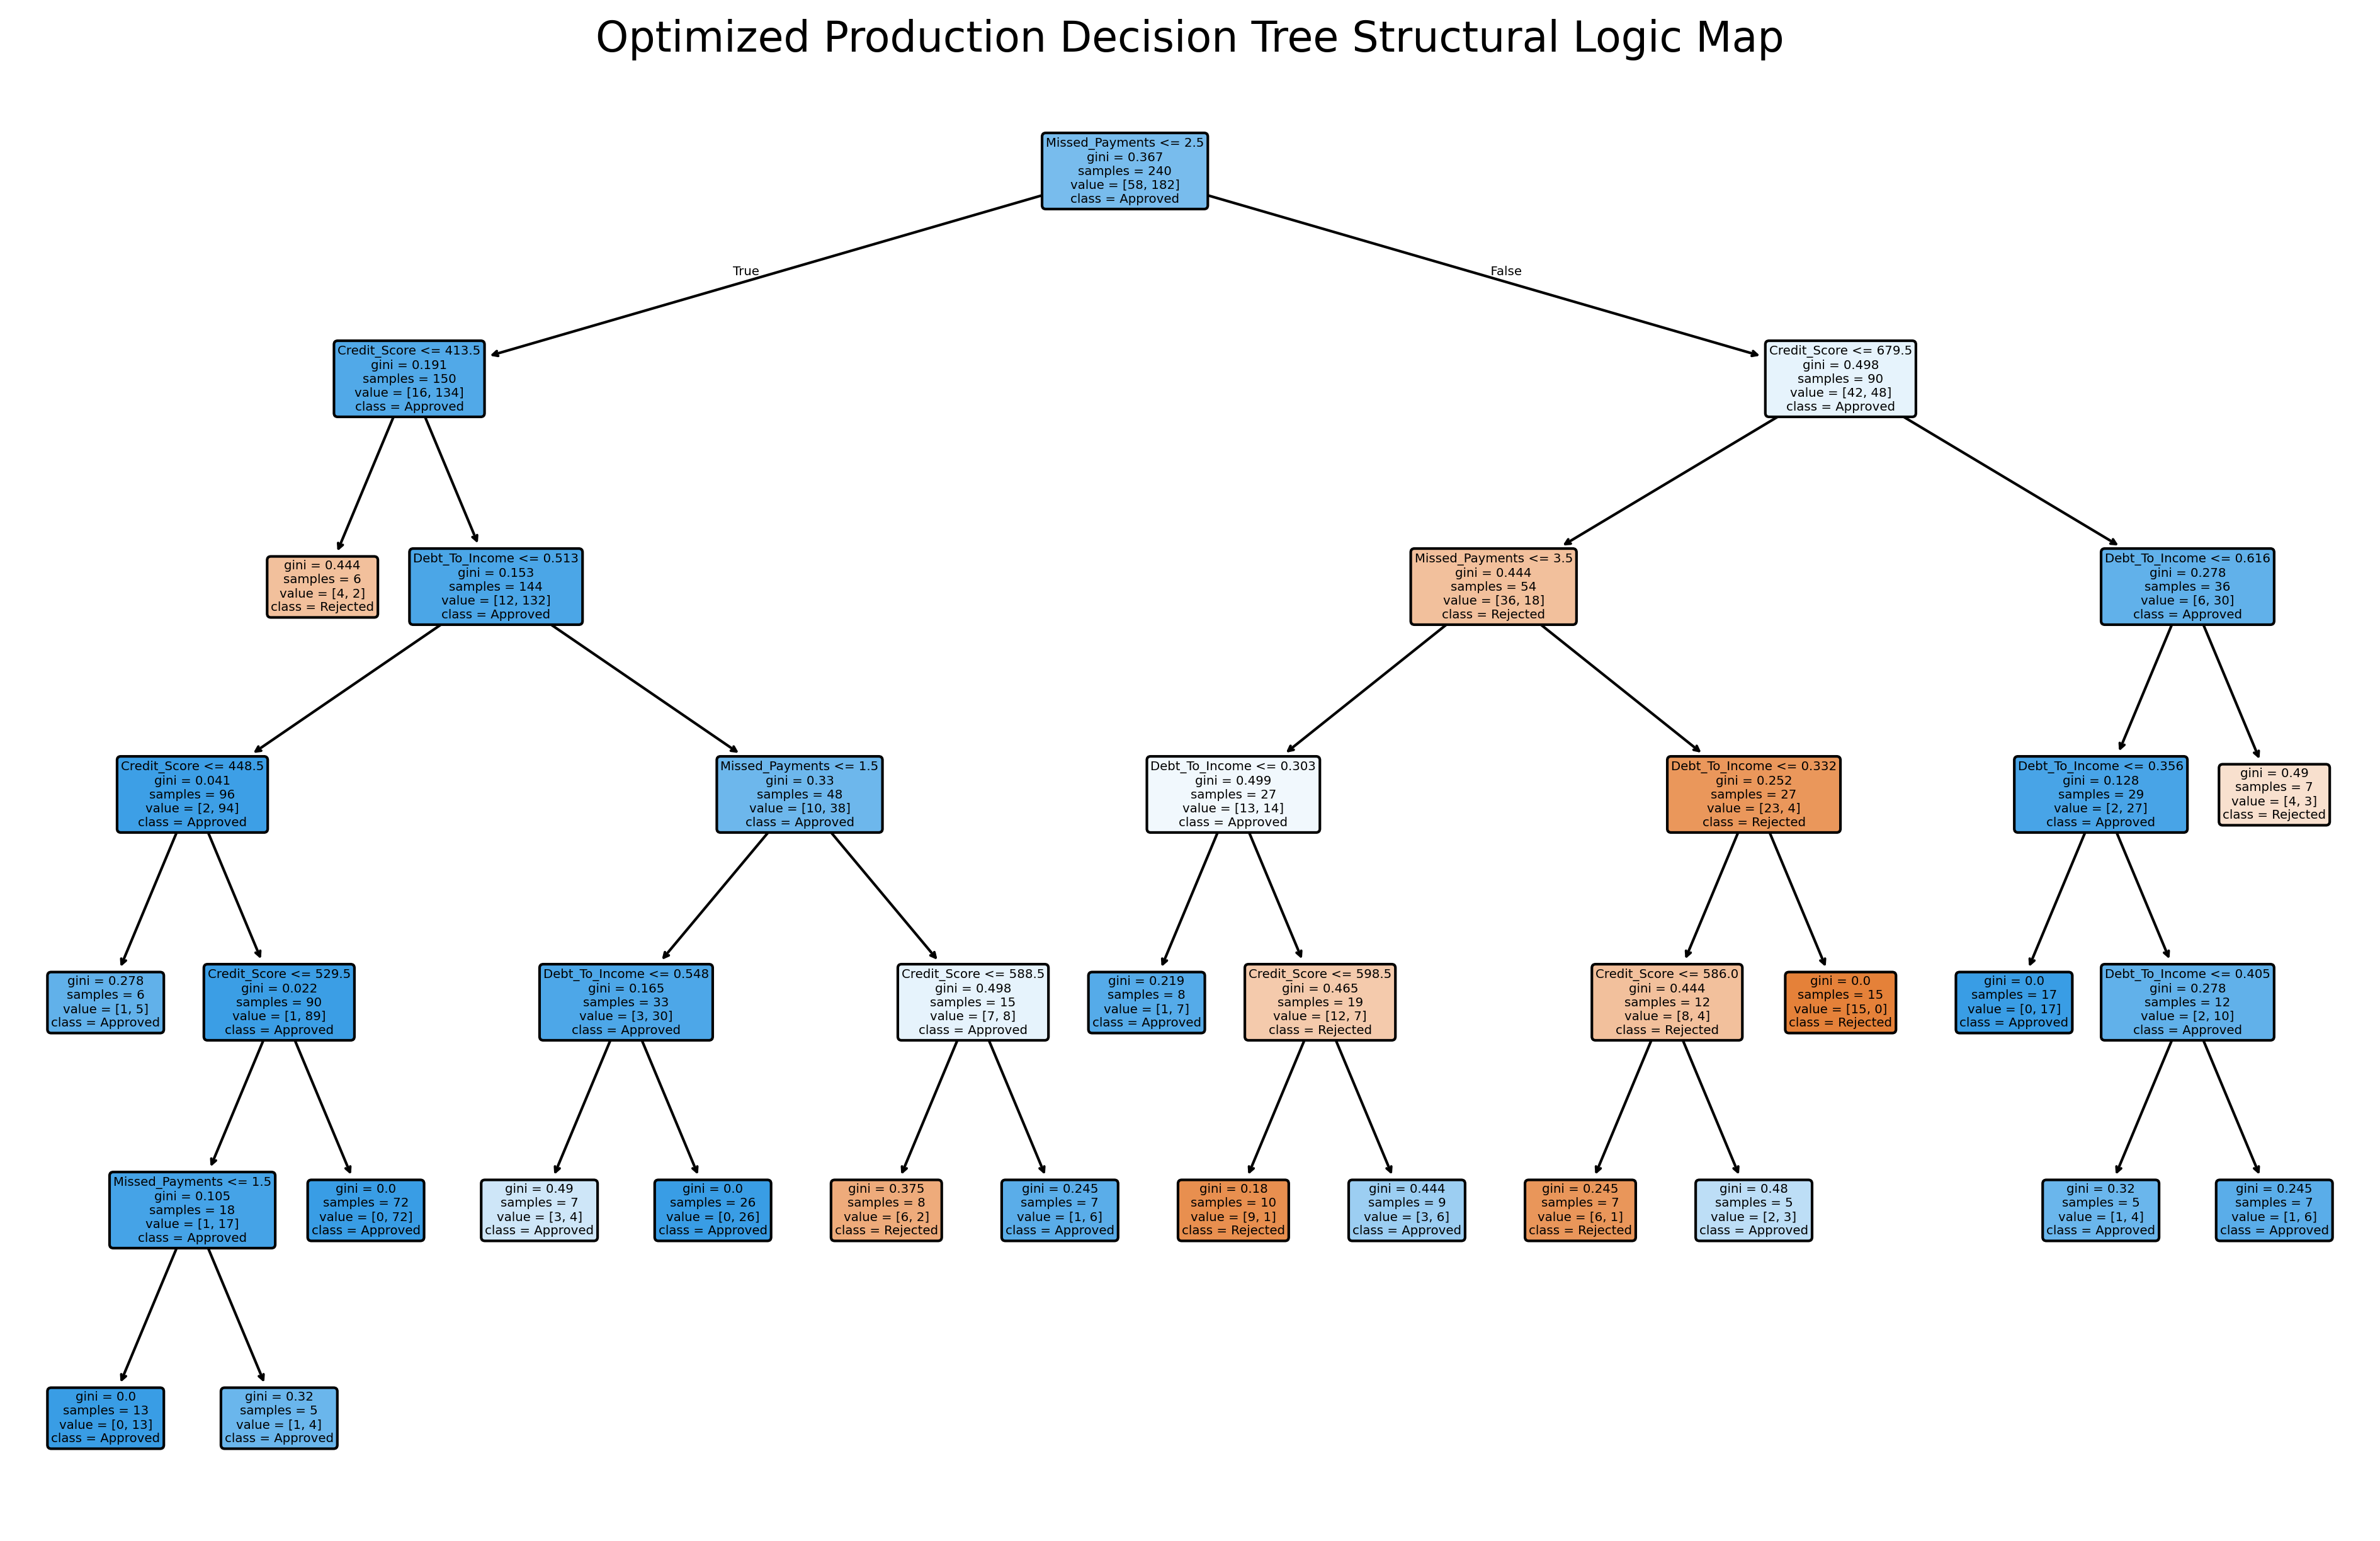

In [47]:
plt.figure(figsize=(16, 10), dpi=300)
plot_tree(
    optimized_tree,
    feature_names=X.columns.tolist(),
    class_names=['Rejected', 'Approved'],
    filled=True,          # Colors nodes based on class purity
    rounded=True,         # Rounds the edges of the boxes
    impurity=True,        # Shows the Gini/Entropy score at every junction
    proportion=False      # Displays absolute raw counts instead of ratios
)
plt.title("Optimized Production Decision Tree Structural Logic Map", fontsize=16)
plt.show()

# **Hands-on Case Study : End-to-End Telco Churn Prediction**

In [48]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [49]:
# ========================================================
# STEP 1: LOAD DATA & GENERATE TARGETS
# ========================================================
np.random.seed(88)
n_customers = 500

In [50]:
tenure_months = np.random.randint(1, 72, n_customers)
monthly_charges = np.random.uniform(20, 120, n_customers)
tech_support_calls = np.random.randint(0, 8, n_customers)

In [51]:
# Define a ground truth churn rule with non-linear interaction noise
churn_score = (0.05 * monthly_charges) + (0.8 * tech_support_calls) - (0.08 * tenure_months) - 2
churn_prob = 1 / (1 + np.exp(-churn_score))
churned = np.random.binomial(1, churn_prob)

In [52]:
case_df = pd.DataFrame({
    'Tenure_Months': tenure_months,
    'Monthly_Charges': monthly_charges,
    'Support_Calls': tech_support_calls,
    'Churn': churned
})

In [53]:
X_case = case_df[['Tenure_Months', 'Monthly_Charges', 'Support_Calls']]
y_case = case_df['Churn']

In [54]:
# ========================================================
# STEP 2: SPLIT & INITIALIZE MODEL
# ========================================================
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_case, y_case, test_size=0.25, random_state=88, stratify=y_case
)

In [55]:
# Building a cost-complexity pruned model to ensure clean generalization
case_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,                  # Prevents deep overfitting
    min_samples_leaf=10,          # Ensures leaf nodes have a representative sample size
    random_state=88
)

In [56]:
case_tree.fit(X_c_train, y_c_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=10,
                       random_state=88)

In [57]:
# ========================================================
# STEP 3: PREDICTION & EXTENSIVE CASE VALIDATION
# ========================================================
predictions_case = case_tree.predict(X_c_test)
probabilities_case = case_tree.predict_proba(X_c_test)[:, 1]


In [58]:
print("======= TELCO CHURN CASE STUDY RESULTS =======")
print(f"Test ROC-AUC Score: {roc_auc_score(y_c_test, probabilities_case):.4f}\n")
print("Detailed Model Classification Performance Profile:")
print(classification_report(y_c_test, predictions_case))

======= TELCO CHURN CASE STUDY RESULTS =======
Test ROC-AUC Score: 0.8253

Detailed Model Classification Performance Profile:
              precision    recall  f1-score   support

           0       0.62      0.62      0.62        40
           1       0.82      0.82      0.82        85

    accuracy                           0.76       125
   macro avg       0.72      0.72      0.72       125
weighted avg       0.76      0.76      0.76       125



In [59]:
# Feature impact mapping
case_importances = pd.DataFrame({
    'Metric Feature': X_case.columns,
    'Weight Contribution': case_tree.feature_importances_
}).sort_values(by='Weight Contribution', ascending=False)


In [60]:
print("Root Feature Contribution Priorities:")
print(case_importances.to_string(index=False))

Root Feature Contribution Priorities:
 Metric Feature  Weight Contribution
  Support_Calls             0.470550
  Tenure_Months             0.285348
Monthly_Charges             0.244102
